# Nosepoke pokes as ON pulses (gap-bridged)

A **poke** is a continuous period during which a nosepoke beam is broken. We take the raw HARP
beam-break stream (`nosepoke:Activations`, a per-port 0/1 signal), and **bridge** any OFF gap
shorter than `N_SECONDS` (treat that `0` as `1`) so a bouncy / chattering / briefly-released
contact reads as one continuous ON period. Each continuous ON period is then **one poke**, with a
start, end, duration, and `n_pulses` (how many raw ON blips got merged into it).

Each poke is assigned to its trial and to the **outbound** leg (`start_time -> tz_triggered`) or
**inbound** leg (`tz_triggered -> end`), and tagged target vs non-target (`CorrectPort`). Figures:
(1) outbound pokes/trial across first/mid/last; (2) outbound vs inbound by outcome; (3) outbound
pokes vs TTT. Finally a **logic check**: the events log records exactly one inbound decision poke
per trial (at `ChosenPort`), so the pulse method should yield ~one inbound poke at `ChosenPort` per
trial - swept over `N_SECONDS` to show which bridge value reproduces it.

In [1]:
# Setup
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_conduit.qc import (
    qc_datastructure, training_spec, training_session_names, filter_trials,
    TRAINING_FIRST_MID_LAST_DETAIL, TRAINING_PHASE_LABELS,
)

ROOT = pathlib.Path('/media/sepi/Elements1/PathIntegrationProtocol/BonsaiOutput/Training')

# A poke = a continuous ON period. Any OFF gap shorter than this many SECONDS is bridged (0 -> 1),
# so a bouncy/held/briefly-released contact becomes one poke. Raise to merge more aggressively.
# The logic-check sweep at the bottom helps you pick it.
N_SECONDS = 0.05

In [2]:
# Load the first/mid/last training sessions (events -> trials; nosepoke -> beam-break stream).
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)
spec['phase'] = spec['training_day'].map(TRAINING_PHASE_LABELS)

datastructure = qc_datastructure(
    root=ROOT, depth=2, level_names=('mouseID', 'day'),
    streams=('events', 'nosepoke'),
    include=training_session_names(spec),
)
result = datastructure.load()
trials_filtered = filter_trials(result['trials'], spec)


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
      mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
FLR_M01569521             1 2026-04-23T160907Z       74         11           64       False             0      64
FLR_M01569521             2 2026-04-28T124013Z       14          6            9       False             0       9
FLR_M01569521             2 2026-04-28T124547Z       68         11           58       False             0      58
FLR_M01569521             3 2026-04-30T151438Z      109          6          104       False             0     104
 FL_M01569519             1 2026-04-21T144313Z       29          2           28       False             0      28
 FL_M01569519             2 2026-04-25T194933Z       22         11           12       False      

In [3]:
# Pulse-based poke extraction: bridge OFF gaps < N_SECONDS, keep each continuous ON period as a poke.
def activations_long(result, key='nosepoke:Activations', *, port_dim='peripherals'):
    """Long-form [session, port, Time, state] from the nosepoke Activations DataArray."""
    df = result[key].to_dataframe(name='state').reset_index()
    return df.rename(columns={port_dim: 'port'})[['session', 'port', 'Time', 'state']]


def poke_pulses(activations_long_df, gap_s, *, high=1, session_col='session',
                port_col='port', time_col='Time', state_col='state'):
    """One row per poke (a continuous ON period), after bridging OFF gaps shorter than gap_s.

    Per (session, port): reduce the stream to state transitions, form ON intervals [rise, fall]
    (edges alternate after de-duplication, so a rising edge's fall is the next transition), then
    MERGE any two ON intervals whose separating OFF gap < gap_s. Each merged run is one poke.
    Columns: t_start, t_end, duration, n_pulses (raw ON blips merged), port_index."""
    a = activations_long_df.dropna(subset=[state_col]).sort_values(
        [session_col, port_col, time_col]).copy()
    a['_prev'] = a.groupby([session_col, port_col])[state_col].shift()
    tr = a[a[state_col] != a['_prev']].copy()                         # state transitions (edges)
    tr['t_fall'] = tr.groupby([session_col, port_col])[time_col].shift(-1)   # next edge = fall for a rise
    ons = tr[tr[state_col] == high].rename(columns={time_col: 't_rise'}).copy()   # ON intervals
    last_t = a.groupby([session_col, port_col])[time_col].max().rename('_last_t')
    ons = ons.merge(last_t, on=[session_col, port_col], how='left')
    ons['t_fall'] = ons['t_fall'].fillna(ons['_last_t'])             # ended ON -> clip to last sample
    ons = ons.sort_values([session_col, port_col, 't_rise'])
    off_gap = ons['t_rise'] - ons.groupby([session_col, port_col])['t_fall'].shift()   # OFF gap before this ON
    ons['_pid'] = (off_gap.isna() | (off_gap >= gap_s)).groupby(
        [ons[session_col], ons[port_col]]).cumsum()                  # new poke where the OFF gap >= gap_s
    pokes = (ons.groupby([session_col, port_col, '_pid'])
             .agg(t_start=('t_rise', 'min'), t_end=('t_fall', 'max'), n_pulses=('t_rise', 'size'))
             .reset_index())
    pokes['duration'] = pokes['t_end'] - pokes['t_start']
    pokes['port_index'] = pokes[port_col].str.split('_').str[-1].astype(int)   # 'NP_5' -> 5
    return pokes[[session_col, port_col, 'port_index', 't_start', 't_end', 'duration', 'n_pulses']]


pokes = poke_pulses(activations_long(result), N_SECONDS)
print(f'{len(pokes)} pokes at N_SECONDS={N_SECONDS:g}s | '
      f'{(pokes["n_pulses"] > 1).mean():.1%} merged >1 raw ON-blip | '
      f'median duration {pokes["duration"].median() * 1000:.0f} ms')
pokes.head()

9263 pokes at N_SECONDS=0.05s | 28.3% merged >1 raw ON-blip | median duration 109 ms


,session,port,port_index,t_start,t_end,duration,n_pulses
0,2026-04-21T144313Z,NP_0,0,18274.919328,18274.958848,0.039520,1
1,2026-04-21T144313Z,NP_0,0,18407.557632,18407.617024,0.059392,1
2,2026-04-21T144313Z,NP_12,12,18203.280128,18203.392864,0.112736,1
3,2026-04-21T144313Z,NP_12,12,18204.258400,18204.439008,0.180608,1
4,2026-04-21T144313Z,NP_12,12,18204.553216,18207.938304,3.385088,2


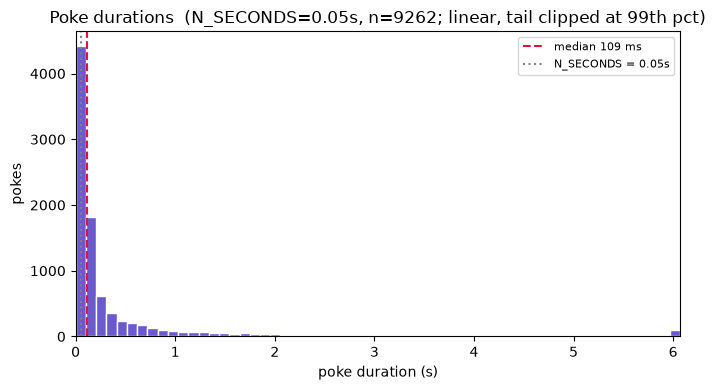

poke duration (s):
count    9262.000000
mean        0.498311
std         1.165105
min         0.001280
10%         0.031520
50%         0.109312
90%         1.302592
99%         6.068776
max        15.917760


In [4]:
# Distribution of poke durations (t_end - t_start, seconds; includes any bridged OFF gaps < N_SECONDS).
_dur = pokes['duration'][pokes['duration'] > 0]
_hi = _dur.quantile(0.99)                     # clip the long-hold tail so the LINEAR axis stays readable
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(_dur.clip(upper=_hi), bins=np.linspace(0, _hi, 60), color='#6a5acd', edgecolor='white')
ax.axvline(_dur.median(), color='crimson', ls='--', label=f'median {_dur.median() * 1000:.0f} ms')
if N_SECONDS <= _hi:
    ax.axvline(N_SECONDS, color='gray', ls=':', label=f'N_SECONDS = {N_SECONDS:g}s')
ax.set_xlim(0, _hi)
ax.set_xlabel('poke duration (s)'); ax.set_ylabel('pokes')
ax.set_title(f'Poke durations  (N_SECONDS={N_SECONDS:g}s, n={len(_dur)}; linear, tail clipped at 99th pct)')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

print('poke duration (s):')
print(_dur.describe(percentiles=[.1, .5, .9, .99]).to_string())

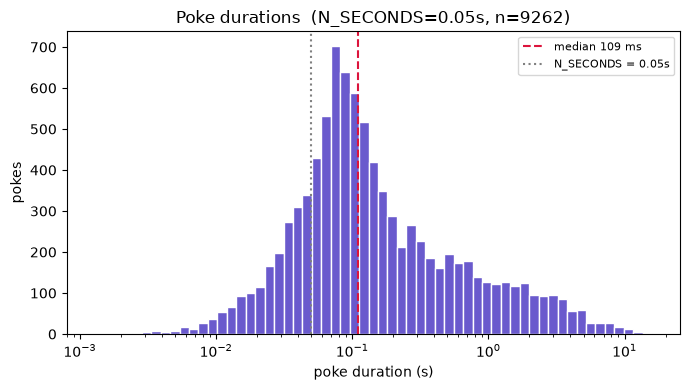

poke duration (s):
count    9262.000000
mean        0.498311
std         1.165105
min         0.001280
10%         0.031520
50%         0.109312
90%         1.302592
99%         6.068776
max        15.917760


In [5]:
# Distribution of poke durations (t_end - t_start, seconds; includes any bridged OFF gaps < N_SECONDS).
_dur = pokes['duration'][pokes['duration'] > 0]
fig, ax = plt.subplots(figsize=(7, 4))
_bins = np.logspace(np.log10(_dur.min()), np.log10(_dur.max()), 60)
ax.hist(_dur, bins=_bins, color='#6a5acd', edgecolor='white'); ax.set_xscale('log')
ax.axvline(_dur.median(), color='crimson', ls='--', label=f'median {_dur.median() * 1000:.0f} ms')
ax.axvline(N_SECONDS, color='gray', ls=':', label=f'N_SECONDS = {N_SECONDS:g}s')
ax.set_xlabel('poke duration (s)'); ax.set_ylabel('pokes')
ax.set_title(f'Poke durations  (N_SECONDS={N_SECONDS:g}s, n={len(_dur)})')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

print('poke duration (s):')
print(_dur.describe(percentiles=[.1, .5, .9, .99]).to_string())

In [6]:
# Assign each poke to its trial + leg (outbound/inbound) + target, then per-trial counts.
def pokes_by_trial(pokes, trials, *, session_col='session'):
    """Tag each poke with its trial, leg and is_target (assigned by the poke's start time)."""
    tw = (trials[[session_col, 'trial_index', 'start_time', 'end_time',
                  'outbound_end_time', 'CorrectPort']].sort_values('start_time').reset_index(drop=True))
    p = pokes.sort_values('t_start').reset_index(drop=True)
    t = pd.merge_asof(p, tw, left_on='t_start', right_on='start_time',
                      by=session_col, direction='backward')
    t = t[(t['t_start'] <= t['end_time']).fillna(False)].copy()
    cutoff = t['outbound_end_time'].fillna(t['end_time'])
    t['leg'] = np.where(t['t_start'] <= cutoff, 'outbound', 'inbound')
    t['is_target'] = t['port_index'] == t['CorrectPort']
    return t


def per_trial_poke_counts(tagged, trials, *, session_col='session'):
    """n_<leg>_all / n_<leg>_target per trial (0 where a trial had no pokes)."""
    g = (tagged.groupby([session_col, 'trial_index', 'leg'])
         .agg(all_=('port_index', 'size'), target=('is_target', 'sum')).reset_index())
    wide = g.pivot_table(index=[session_col, 'trial_index'], columns='leg',
                         values=['all_', 'target'], fill_value=0)
    wide.columns = [f'n_{leg}_{"all" if k == "all_" else "target"}' for k, leg in wide.columns]
    wide = wide.reset_index()
    out = trials.merge(wide, on=[session_col, 'trial_index'], how='left')
    for c in [c for c in wide.columns if c.startswith('n_')]:
        out[c] = out[c].fillna(0).astype(int)
    return out


tagged = pokes_by_trial(pokes, trials_filtered)
poke_trials = per_trial_poke_counts(tagged, trials_filtered)
poke_trials[['mouseID', 'training_day', 'trial_index', 'outcome', 'TTT',
             'n_outbound_all', 'n_outbound_target', 'n_inbound_all']]

,mouseID,training_day,trial_index,outcome,TTT,n_outbound_all,n_outbound_target,n_inbound_all
0,FLR_M01569521,1,11,Miss,7.179488,10,10,0
1,FLR_M01569521,1,12,Success,6.083008,2,2,1
2,FLR_M01569521,1,13,Success,6.446976,1,1,1
3,FLR_M01569521,1,14,Miss,6.457504,3,3,0
4,FLR_M01569521,1,15,Miss,9.236992,0,0,0
...,...,...,...,...,...,...,...,...
1104,MbR_M01569518,3,109,Success,10.828000,0,0,0
1105,MbR_M01569518,3,110,Success,9.014496,0,0,0
1106,MbR_M01569518,3,111,Success,11.032992,0,0,0
1107,MbR_M01569518,3,112,Success,18.554016,0,0,0


In [7]:
# Plot helpers.
DEFAULT_MOUSE_COLOURS = {
    'FLR_M01569521': '#f994b1', 'FbR_M01569522': '#e53592', 'FL_M01569519': '#950041',
    'MR_M01569515': '#73a9cf', 'MbR_M01569518': '#2e7ebc', 'MbL_M01569517': '#004cd9',
}
PHASE_TICKS = [1, 2, 3]


def plot_pokes_per_day(poke_trials, ax, count_col, title, *,
                       mouse_colours=DEFAULT_MOUSE_COLOURS, mouse_col='mouseID', day_col='training_day'):
    s = poke_trials.groupby([mouse_col, day_col])[count_col].mean().reset_index()
    for m in [m for m in mouse_colours if m in set(s[mouse_col])]:
        d = s[s[mouse_col] == m]
        ax.plot(d[day_col], d[count_col], 'o-', color=mouse_colours[m], alpha=0.55, label=m)
    gm = s.groupby(day_col)[count_col].mean()
    ax.plot(gm.index, gm.values, 'ko-', linewidth=2.5, label='group mean')
    ax.set_title(title); ax.set_xlabel('training day'); ax.set_xticks(PHASE_TICKS)
    ax.set_xticklabels([TRAINING_PHASE_LABELS.get(t, t) for t in PHASE_TICKS])


def plot_outbound_vs_inbound(poke_trials, ax, *, outcomes=('Success', 'Failure', 'Miss')):
    m = (poke_trials.groupby('outcome')[['n_outbound_all', 'n_inbound_all']].mean().reindex(outcomes))
    x = np.arange(len(m)); w = 0.38
    ax.bar(x - w / 2, m['n_outbound_all'], w, label='outbound', color='#6a5acd')
    ax.bar(x + w / 2, m['n_inbound_all'], w, label='inbound', color='#2e8b57')
    ax.set_xticks(x); ax.set_xticklabels(m.index)
    ax.set_ylabel('mean pokes / trial'); ax.set_title('Outbound vs inbound by outcome'); ax.legend()


def plot_pokes_vs_ttt(poke_trials, ax, *, count_col='n_outbound_all'):
    d = poke_trials.dropna(subset=['TTT', count_col])
    ax.scatter(d['TTT'], d[count_col], s=10, alpha=0.35, color='#6a5acd')
    if len(d) > 2:
        sl, ic = np.polyfit(d['TTT'], d[count_col], 1)
        xr = np.array([d['TTT'].min(), d['TTT'].max()])
        ax.plot(xr, sl * xr + ic, '--', color='crimson', label=f'slope={sl:.2f}/s'); ax.legend()
    ax.set_xlabel('TTT (s)'); ax.set_ylabel('outbound pokes / trial')
    ax.set_title('Outbound pokes vs time-to-target')

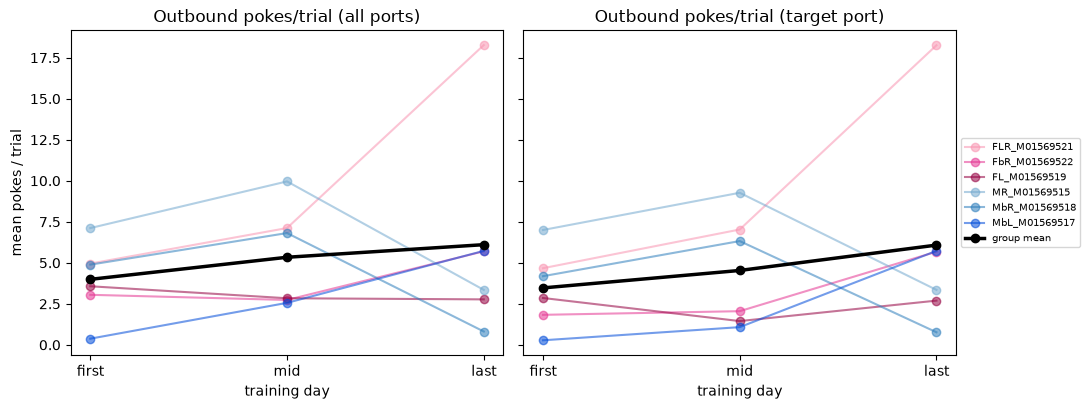

In [8]:
# Figure 1 | Outbound pokes/trial across first/mid/last (all ports + target port).
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
plot_pokes_per_day(poke_trials, axes[0], 'n_outbound_all', 'Outbound pokes/trial (all ports)')
plot_pokes_per_day(poke_trials, axes[1], 'n_outbound_target', 'Outbound pokes/trial (target port)')
axes[0].set_ylabel('mean pokes / trial')
axes[1].legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.tight_layout(); plt.show()

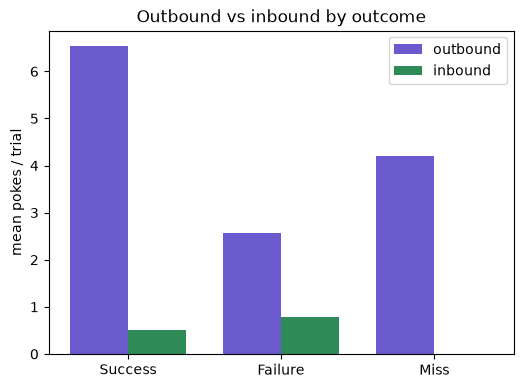

In [9]:
# Figure 2 | Outbound vs inbound pokes by outcome.
fig, ax = plt.subplots(figsize=(6, 4.2))
plot_outbound_vs_inbound(poke_trials, ax)
plt.show()

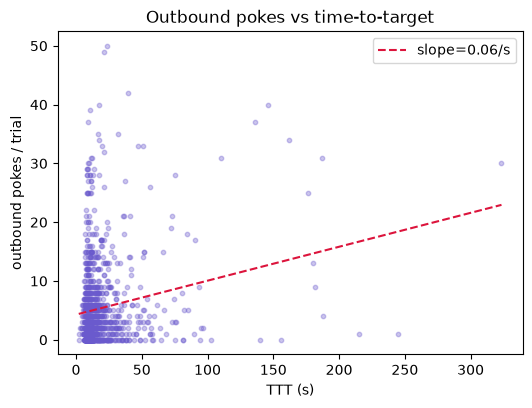

In [10]:
# Figure 3 | Outbound pokes vs TTT.
fig, ax = plt.subplots(figsize=(6, 4.2))
plot_pokes_vs_ttt(poke_trials, ax)
plt.show()

## Logic check — pulse pokes vs the events-log inbound poke

The events log records exactly **one** poke per trial: the inbound decision poke at `ChosenPort`.
So the pulse method should give ~**one** inbound poke at `ChosenPort` per decision trial. We sweep
`N_SECONDS` and report, per decision trial: `== 1` (matches), `> 1` (under-bridged / still split),
`== 0` (the poke's start fell in the outbound leg - a hold). The bridge value where `>1` collapses
toward 0 while `==1` peaks is the one that best reproduces the events log.

,N_SECONDS,match_1,over_1,zero,mean_pokes
0,0.02,0.552,0.0,0.448,0.552
1,0.05,0.552,0.0,0.448,0.552
2,0.10,0.552,0.0,0.448,0.552
3,0.25,0.552,0.0,0.448,0.552
4,0.50,0.552,0.0,0.448,0.552
5,1.00,0.552,0.0,0.448,0.552
6,2.00,0.552,0.0,0.448,0.552


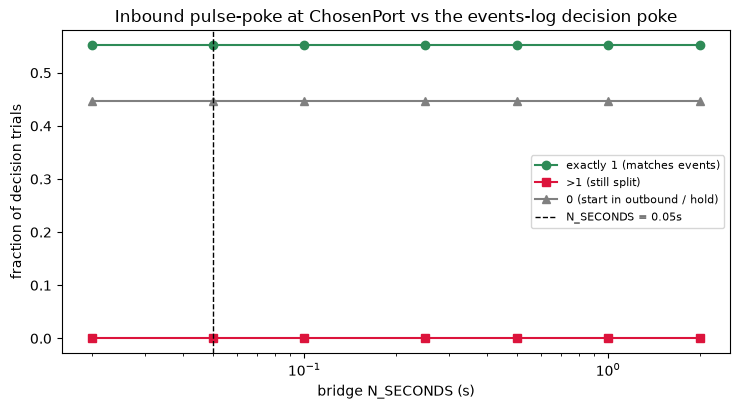

In [11]:
# Sweep N_SECONDS; count inbound pulse-pokes at ChosenPort per decision trial vs the events log's 1.
def inbound_chosen_counts(pokes, trials, *, session_col='session'):
    tw = (trials[[session_col, 'trial_index', 'start_time', 'end_time', 'outbound_end_time',
                  'ChosenPort']].sort_values('start_time').reset_index(drop=True))
    p = pokes.sort_values('t_start').reset_index(drop=True)
    t = pd.merge_asof(p, tw, left_on='t_start', right_on='start_time', by=session_col, direction='backward')
    t = t[(t['t_start'] <= t['end_time']).fillna(False)].copy()
    cutoff = t['outbound_end_time'].fillna(t['end_time'])
    t = t[(t['t_start'] > cutoff) & (t['port_index'] == t['ChosenPort'])]   # inbound pokes at ChosenPort
    inb = t.groupby([session_col, 'trial_index']).size()
    dec = trials[trials['ChosenPort'] >= 0][[session_col, 'trial_index']].copy()   # real decision pokes only
    dec['n'] = [inb.get((s, ti), 0) for s, ti in zip(dec[session_col], dec['trial_index'])]
    return dec['n']


_al = activations_long(result)
_sweep = [0.02, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]
_rows = []
for _g in _sweep:
    _n = inbound_chosen_counts(poke_pulses(_al, _g), trials_filtered)
    _rows.append({'N_SECONDS': _g, 'match_1': (_n == 1).mean(), 'over_1': (_n > 1).mean(),
                  'zero': (_n == 0).mean(), 'mean_pokes': _n.mean()})
sweep_df = pd.DataFrame(_rows)
display(sweep_df.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(sweep_df['N_SECONDS'], sweep_df['match_1'], 'o-', color='#2e8b57', label='exactly 1 (matches events)')
ax.plot(sweep_df['N_SECONDS'], sweep_df['over_1'], 's-', color='crimson', label='>1 (still split)')
ax.plot(sweep_df['N_SECONDS'], sweep_df['zero'], '^-', color='gray', label='0 (start in outbound / hold)')
ax.axvline(N_SECONDS, color='k', ls='--', lw=1, label=f'N_SECONDS = {N_SECONDS:g}s')
ax.set_xscale('log'); ax.set_xlabel('bridge N_SECONDS (s)'); ax.set_ylabel('fraction of decision trials')
ax.set_title('Inbound pulse-poke at ChosenPort vs the events-log decision poke')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## Temporal alignment — do the events poke and the Activations poke coincide in time?

The key criterion: for each **events** decision poke (fires at `end_time`, at `ChosenPort`), is there
an **Activations** poke at that same port whose interval `[t_start, t_end]` *contains* `end_time`?
If so, the two logs agree in time. Unlike the count check above, this credits holds (a poke that
started in outbound but still spans the inbound decision), so it measures pure time alignment.
`offset = end_time - t_start` is how long after the beam broke the events logic fired.

784 events decision pokes:
  87.8% fall INSIDE a ChosenPort Activations poke  (events & activations coincide in time)
  offset (events time - poke start) on those: median 2 ms, 90th pct 3 ms
  1.5% had NO ChosenPort poke starting before the event at all


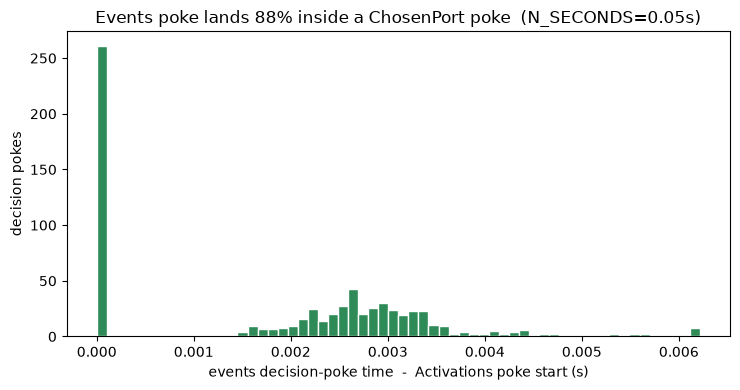

In [12]:
# Match each events decision poke (end_time, ChosenPort) to the ChosenPort Activations poke that
# started at/before it; they 'line up in time' if end_time falls inside that poke's [t_start, t_end].
def decision_time_alignment(pokes, trials, *, session_col='session'):
    dec = (trials[trials['ChosenPort'] >= 0][[session_col, 'trial_index', 'end_time', 'ChosenPort']]
           .dropna(subset=['end_time']).sort_values('end_time').reset_index(drop=True))
    pk = (pokes.rename(columns={'port_index': 'ChosenPort'})[[session_col, 'ChosenPort', 't_start', 't_end']]
          .sort_values('t_start').reset_index(drop=True))
    m = pd.merge_asof(dec, pk, left_on='end_time', right_on='t_start',
                      by=[session_col, 'ChosenPort'], direction='backward')
    m['offset'] = m['end_time'] - m['t_start']                 # s from beam-break start to the logged poke
    m['contained'] = (m['end_time'] >= m['t_start']) & (m['end_time'] <= m['t_end'])
    return m


align = decision_time_alignment(pokes, trials_filtered)
_in = align['contained']
_off = align.loc[_in, 'offset']
print(f'{len(align)} events decision pokes:')
print(f'  {_in.mean():.1%} fall INSIDE a ChosenPort Activations poke  (events & activations coincide in time)')
print(f'  offset (events time - poke start) on those: median {_off.median() * 1000:.0f} ms, '
      f'90th pct {_off.quantile(.9) * 1000:.0f} ms')
print(f'  {align["t_start"].isna().mean():.1%} had NO ChosenPort poke starting before the event at all')

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(_off.clip(upper=_off.quantile(0.99)), bins=60, color='#2e8b57', edgecolor='white')
ax.set_xlabel('events decision-poke time  -  Activations poke start (s)')
ax.set_ylabel('decision pokes')
ax.set_title(f'Events poke lands {_in.mean():.0%} inside a ChosenPort poke  (N_SECONDS={N_SECONDS:g}s)')
fig.tight_layout(); plt.show()